In [45]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
dataset_path = '/Users/trevinrodrigo/Desktop/new project/cost_of_living_us.csv'
data = pd.read_csv(dataset_path)


In [47]:
def extract_family_count(family_member):
   
    parent_count = int(family_member.split('p')[0])  # Number of parents
    child_count = int(family_member.split('p')[1].replace('c', ''))  # Number of children
    return parent_count, child_count


In [48]:
data[['parent_count', 'child_count']] = data['family_member_count'].apply(lambda x: pd.Series(extract_family_count(x)))

In [49]:

le_state = LabelEncoder()
le_areaname = LabelEncoder()

data['state'] = le_state.fit_transform(data['state'])
data['areaname'] = le_areaname.fit_transform(data['areaname'])
data['needs_childcare'] = data['childcare_cost'].apply(lambda x: 1 if x > 0 else 0)


In [50]:
features = ['state', 'areaname', 'parent_count', 'child_count', 'housing_cost', 'food_cost', 
            'transportation_cost', 'healthcare_cost', 'other_necessities_cost', 
            'childcare_cost', 'taxes']
target = 'total_cost'


In [51]:

X = data[features]
y = data[target]
model = LinearRegression()
model.fit(X, y)



LinearRegression()

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X)


mae = mean_absolute_error(y, y_pred)

rmse = np.sqrt(mean_squared_error(y, y_pred))


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 0.0015560486474369083
Root Mean Squared Error (RMSE): 0.0019795913041008423


In [53]:
from sklearn.metrics import r2_score


r2 = r2_score(y, y_pred)

print(f"R-squared (R²): {r2}") #0.99 means the modelm is accurate 

R-squared (R²): 0.9999999999999918


In [54]:
joblib.dump(model, 'full_model.pkl')
joblib.dump(le_state, 'state_encoder.pkl')
joblib.dump(le_areaname, 'area_encoder.pkl')


['area_encoder.pkl']

In [57]:
lookup_df = data[['state', 'isMetro', 'parent_count', 'child_count', 'needs_childcare', 'total_cost', 'median_family_income']]
lookup_df.to_csv('cost_lookup.csv', index=False)


In [55]:
group_cols = ['state', 'isMetro', 'parent_count', 'child_count', 'needs_childcare']
cost_cols = ['housing_cost', 'food_cost', 'transportation_cost', 'healthcare_cost',
             'other_necessities_cost', 'childcare_cost', 'taxes']
cost_medians = data.groupby(group_cols)[cost_cols].median().reset_index()
cost_medians.to_csv('cost_medians_lookup.csv', index=False)

In [56]:
#Visualizations 

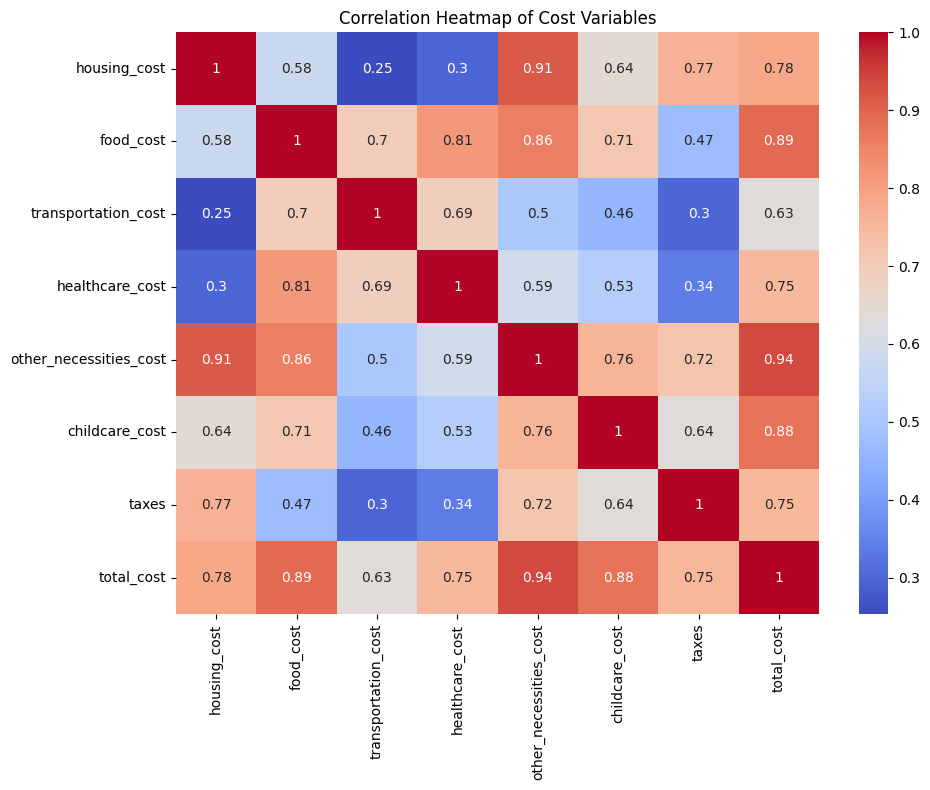

In [41]:
plt.figure(figsize=(10, 8))
corr = data[['housing_cost', 'food_cost', 'transportation_cost', 'healthcare_cost',
           'other_necessities_cost', 'childcare_cost', 'taxes', 'total_cost']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Cost Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

plt.show()

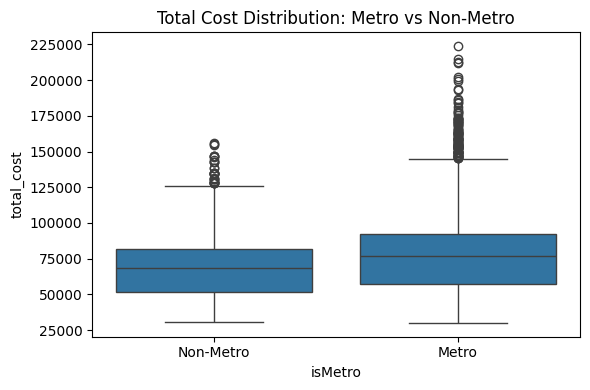

In [42]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['isMetro'], y=data['total_cost'])
plt.xticks([0, 1], ['Non-Metro', 'Metro'])
plt.title('Total Cost Distribution: Metro vs Non-Metro')
plt.tight_layout()
plt.savefig('metro_vs_cost.png')
plt.show()

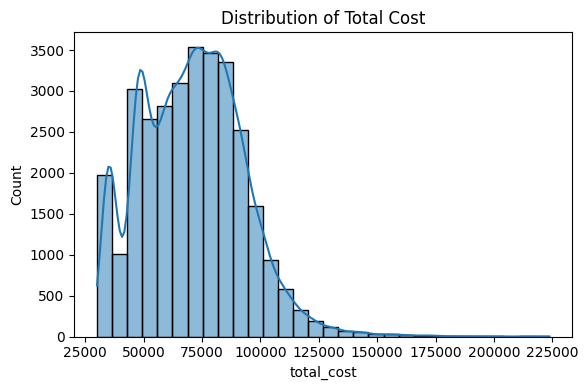

In [43]:
plt.figure(figsize=(6, 4))
sns.histplot(data['total_cost'], bins=30, kde=True)
plt.title('Distribution of Total Cost')
plt.tight_layout()
plt.savefig('total_cost_distribution.png')
plt.show()
